In [8]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt


from kineticanalysis.generator.generator_track import (generate_tracks, generate_one_track)
from kineticanalysis.analysis.analysis_track import single_track_analysis, check_track_validity

In [9]:
path_save = "/home/u2175049/Documents/Code/KineticAnalysis/notebook/figures/"
path = "/mnt/sda1/Sophie/2-KineticAnalysisData/2-Datas/05-Modelling/09_Stitch/"

In [10]:
prot_aa_size = {
    "32xsuntag": 796,  #768/32=24 , left 28
    "linker": 4,
    "twist": 490,
    "ilp4": 134,
    "snail": 390,
    "very_long_prot":1200, 
}

In [4]:
# combine track

def combine_2_track(y1, y2) :
    
    y1_norm = y1/np.mean(y1)
    y2_norm = y2/np.mean(y2)
    y_concat = np.concatenate([y1_norm, y2_norm])
    return y_concat

def combine_n_tracks(list_track = []):
    if len(list_track) == 0 :
        return None

    y_concat = np.empty(shape=[0])
    i=0
    for l in list_track:
        if len(l)!=0:
            # print("----------------------")
            # print(l)
            if i == 0:
                y_concat = np.concatenate([y_concat, l])
                i+=1
            else:
                last_val = y_concat[-1]
                diff_ = last_val - l[0]
                
                # print((l+diff_)[1:])
                y_concat = np.concatenate([y_concat, (l+diff_)[1:]])

    return y_concat



In [ ]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
elongation_rate = 5
for i in range(500):
    x_global, y_global, y_start_prot = generate_one_track(prot_length = prot_aa_size["very_long_prot"], 
                                                      suntag_length = prot_aa_size["32xsuntag"], 
                                                      nb_suntag=32, 
                                                      fluo_one_suntag=4, 
                                                      translation_rate=elongation_rate, 
                                                      binding_rate=0.05,
                                                      step = 0.1,
                                                      length=85000, 
                                                    remove_point_beginning=10000)
    if i == 0:
        datas = pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })
    else:
        datas = pd.concat([datas, 
                           pd.DataFrame({"FRAME":x_global,
                          "MEAN_INTENSITY_CH1":y_global,
                          "TRACK_ID" : i
                             })], ignore_index=True)

datas.to_csv(os.path.join(path, "datas_track_length_translation_rate_5.csv"))

In [12]:
datas = pd.read_csv(os.path.join(path, "datas_track_length_translation_rate_5.csv"), index_col="Unnamed: 0")
datas

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
np.array([2, 5, 8, 10, 15, 20, 25, 30])*60

In [ ]:
prot_length = prot_aa_size["32xsuntag"]+prot_aa_size["very_long_prot"]
first = True

for t in [30]:
# t = 50

    dt = t*0.1
    # for length_track in [60, 120, 300,480,600,900,1200,1500,1800 ]:
    for length_track in [60,119,178,355,532,650,945,1240,1535,1830]:
        print(length_track)
        
        for i in range(500):
            datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
            datas2["FRAME"] = np.arange(length_track)
            if (len(np.unique(datas2["MEAN_INTENSITY_CH1"])) > 1) & (len(datas2) in [60,119,178,355,532,650,945,1240,1535,1830]):
                
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, 
                 y_auto, 
                 k, c,
                 elongation_r, 
                 translation_init_r,
                 perr) = single_track_analysis(x, 
                                             y, 
                                             delta_t = dt,
                                             protein_size=prot_aa_size["very_long_prot"],
                                             suntag_size =prot_aa_size["32xsuntag"], 
                                             repetition_suntag = 32,
                                             mm=None,
                                             method="exact",
                                             simulation=True)
                if first:
                    results = pd.DataFrame({"elongation_r":elongation_r, 
                                            "init_translation_r":translation_init_r, 
                                            "dt":dt,
                                            "long_track":datas2.shape[0],
                                            "k":k,
                                            "c":c,
                                           "id":i,
                                           "stitch":False},
                                          index=[0])
                    first = False
                
                else:
                    results = pd.concat([results, 
                                    pd.DataFrame({"elongation_r":elongation_r, 
                                                  "init_translation_r":translation_init_r, 
                                                  "dt":dt, 
                                                  "long_track":datas2.shape[0],
                                                  "k":k,
                                                  "c":c,
                                                  "id":i,
                                                 "stitch":False}, index=[0])
                                    ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"))

In [13]:
datas = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"), index_col="Unnamed: 0")

In [14]:
results

,elongation_r,init_translation_r,dt,long_track,k,c,id,stitch
0,28.179490,1.117148,3.0,60,1.132844,1.117148,0,False
1,33.903150,14.714749,3.0,60,1.362941,14.714749,1,False
2,26.030872,0.482558,3.0,60,1.046467,0.482558,2,False
3,26.055242,0.931370,3.0,60,1.047447,0.931370,3,False
4,29.634465,3.863893,3.0,60,1.191335,3.863893,4,False
...,...,...,...,...,...,...,...,...
5345,1.381362,0.008205,3.0,1181,0.055532,0.008205,550,True
5346,1.883162,0.011443,3.0,1181,0.075705,0.011443,560,True
5347,NaN,NaN,3.0,1181,NaN,NaN,570,True
5348,NaN,NaN,3.0,1181,NaN,NaN,580,True


In [ ]:
results = results[results["stitch"]==False]

In [ ]:
for nb_combine in [1, 2, 5, 8, 10, 15, 20]: #, 25, 30]:
    for t in [30]:
    # t = 50
    
        dt = t*0.1
        for length_track in [60]:
            print(length_track)
            
            for i in range(50):
                i*=10
                l_track = [datas[datas["TRACK_ID"]==i][::t][:length_track]["MEAN_INTENSITY_CH1"].to_numpy()]
                for j in range (1, nb_combine):
                    pos = i+j
                    if pos>=10:
                        pos-=10
                        
                    l_track.append(datas[datas["TRACK_ID"]==pos][::t][:length_track]["MEAN_INTENSITY_CH1"].to_numpy())
    
                y_combined = combine_n_tracks(l_track)
                datas2 = pd.DataFrame({"TRACK_ID":i, 
                                      "MEAN_INTENSITY_CH1": y_combined,
                                      "FRAME": np.arange(len(y_combined))})
                
                # datas2 = datas[datas["TRACK_ID"]==i][::t][:length_track]
                # datas2["FRAME"] = np.arange(length_track)
    
                # fig, ax = plt.subplots()
                # cpt = 0
                # ax.plot(datas2["MEAN_INTENSITY_CH1"], '--', alpha=0.5, color="black")
                # for l in l_track:
                #     ax.plot(np.arange(len(l))+cpt, l)
                #     cpt += len(l)
                    
                (valid, x, y, x_fix, y_fix) = check_track_validity(datas2,
                                                       i,
                                                       normalise_intensity=1,
                                                       delta_t=dt,
                                                       rtol=1e-1,
                                                       nb_missing_point=0,
                                                       )
    
                
                (x_auto, 
                 y_auto, 
                 k, c,
                 elongation_r, 
                 translation_init_r,
                 perr) = single_track_analysis(x, 
                                             y, 
                                             delta_t = dt,
                                             protein_size=prot_aa_size["very_long_prot"],
                                             suntag_size =prot_aa_size["32xsuntag"], 
                                             repetition_suntag = 32,
                                             mm=None,
                                             method="exact",
                                             simulation=True)
                
    
                results = pd.concat([results, 
                                pd.DataFrame({"elongation_r":elongation_r, 
                                              "init_translation_r":translation_init_r, 
                                              "dt":dt, 
                                              "long_track":datas2.shape[0],
                                              "k":k,
                                                "c":c,
                                              "id":100+i,
                                             "stitch":True}, index=[0])
                                ], ignore_index=True)
                        
results.to_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"))

In [15]:
results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_5.csv"), index_col="Unnamed: 0")

In [ ]:
results = pd.read_csv(os.path.join(path, "results_dt_track_length_translation_rate_24.csv"), index_col="Unnamed: 0")

In [16]:
results.groupby(by=['dt', 'stitch', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].mean()

elongation_r  init_translation_r         k         c
dt  stitch long_track                                                      
3.0 False  60             45.987379            9.309987  1.848739  9.309987
           119            22.276405            1.855685  0.895534  1.855685
           178            15.295566            0.892673  0.614897  0.892673
           355             8.750856            0.210564  0.351793  0.210564
           532             7.356065            0.131867  0.295721  0.131867
           650             6.853751            0.109938  0.275528  0.109938
           945             6.302783            0.086486  0.253378  0.086486
           1240            6.001024            0.075650  0.241247  0.075650
           1535            5.814584            0.070314  0.233752  0.070314
           1830            5.674584            0.065965  0.228124  0.065965
    True   60             42.182151            6.185019  1.695765  6.185019
           119            22.175297            1.647008  0.891469  1.647008
           296             9.198788            0.304650  0.369801  0.304650
           473             6.338951            0.147108  0.254832  0.147108
           591             5.303173            0.105878  0.213193  0.105878
           886             3.585129            0.046813  0.144126  0.046813
           1181            2.818833            0.028526  0.113320  0.028526

In [7]:
results.groupby(by=['dt', 'long_track'])[['elongation_r','init_translation_r', 'k', 'c']].std()

elongation_r  init_translation_r         k          c
dt  long_track                                                       
3.0 60             23.941215           15.510495  0.962461  15.510495
    119            10.329967            2.681526  0.415275   2.681526
    178             7.987937            1.642111  0.321123   1.642111
    296             4.195058            0.575351  0.168646   0.575351
    355             3.207846            0.252891  0.128959   0.252891
    473             3.069452            0.203759  0.123395   0.203759
    532             2.422326            0.144272  0.097380   0.144272
    591             2.509009            0.167554  0.100865   0.167554
    650             2.142445            0.103854  0.086128   0.103854
    886             1.882634            0.076145  0.075684   0.076145
    945             1.911317            0.066651  0.076837   0.066651
    1181            1.367349            0.027353  0.054969   0.027353
    1240            1.707134            0.051555  0.068628   0.051555
    1535            1.571468            0.047012  0.063175   0.047012
    1830            1.469901            0.036802  0.059091   0.036802

ValueError: zero-size array to reduction operation minimum which has no identity

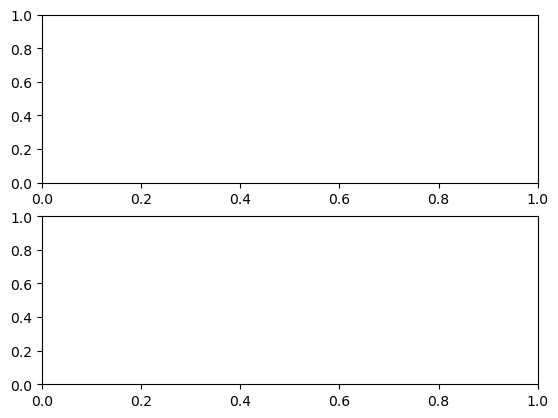

In [17]:
fig, ax = plt.subplots(2,1)


violin = ax[0].violinplot(dataset = [results[ (results.long_track == length_track)]["elongation_r"].values for length_track in [120,1240]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1
# results.boxplot(['init_translation_r'] , 
#                by=['dt', "long_track"], 
#                grid=False, 
#                ax = ax[1],
#                rot=90,
#                boxprops=dict(linestyle='-', linewidth=1.5, color="black"),
#                medianprops=dict(linestyle='-', linewidth=1.5, color="red"),
#                )


violin = ax[1].violinplot(dataset = [results[(results.long_track == length_track)]["init_translation_r"].values for length_track in [120,1240]],
     showmeans=True,
      showmedians=True)

for pc in violin["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("lightgrey")
    pc.set_alpha(0.5)
    
colors = ["black", "black", "black", "red", "green"]
i=0
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    vp = violin[partname]
    vp.set_edgecolor(colors[i])
    vp.set_linewidth(1)
    i+=1

group = ['dt', "long_track"]
column = 'elongation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[0].scatter(x, val, c='grey', alpha=1, s=10)
    
group = ['dt', "long_track"]
column = 'init_translation_r'
grouped = results.groupby(group)
names, vals, xs = [], [] ,[]
for i, (name, subdf) in enumerate(grouped):
    if name[0] == 60:
        names.append(name)
        vals.append(subdf[column][subdf[column]>0].to_list())
        xs.append(np.random.normal(i+1-20, 0.04, subdf[column][subdf[column]>0].shape[0]))
clevels = np.linspace(0., 1., len(grouped))
for x, val, clevel in zip(xs, vals, clevels):
    ax[1].scatter(x, val, c='grey', alpha=1, s=20)

def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)
    ax.set_xlim(0.25, len(labels) + 0.75)
    ax.set_xlabel('Number of point')
# set style for the axes
labels =[30,60,300,600,1200,1800,2700,3600]
for a in ax:
    set_axis_style(a, labels)

ax[0].set_ylabel("Estimate elongation rate")
ax[1].set_ylabel("Estimate initiation rate")

# ax[0].set_ylim(-5,50)
# ax[1].set_ylim(-1, 20)
ax[0].hlines(elongation_rate, 0.5, 9.5)
ax[1].hlines(0.05, 0.5, 9.5)
fig.set_size_inches((10,15))
# fig.savefig(os.path.join(path_save, "results_length_boxplot_exact_dt1_0.05_5.eps"), dpi=300)

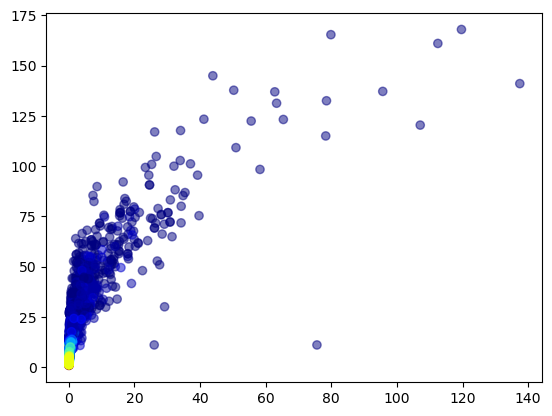

In [18]:
fig, ax = plt.subplots()
ax.scatter(results["init_translation_r"], results["elongation_r"], c=results["long_track"], cmap="jet", alpha=0.5)
# ax.set_xlim(0,50)
# ax.set_ylim(0,50)

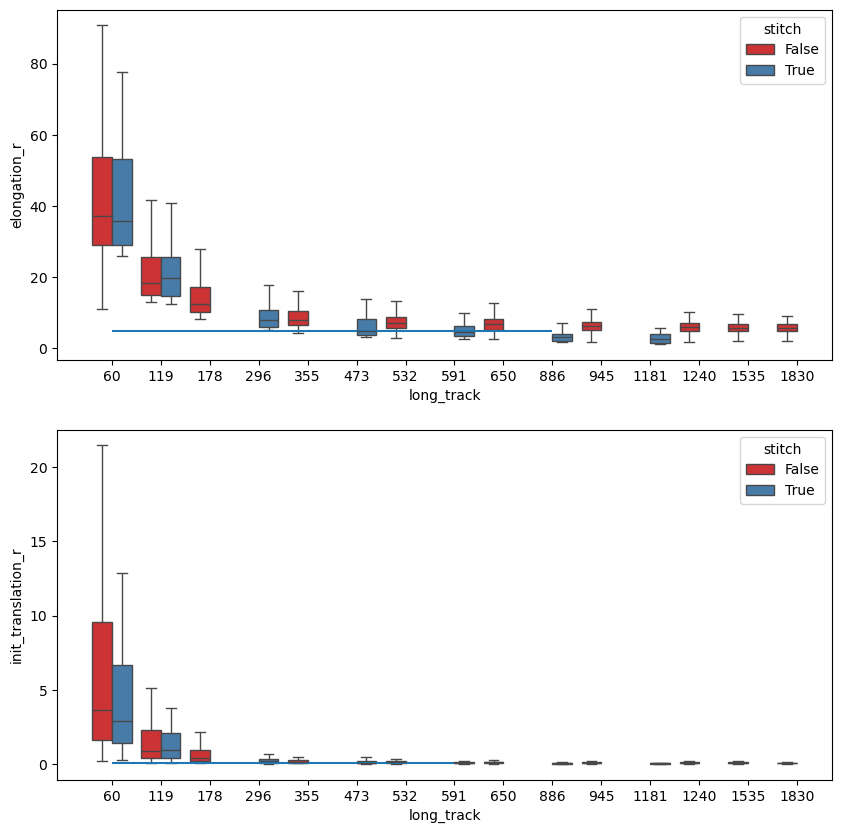

In [20]:
import seaborn as sns
elongation_rate=5
fig, axes = plt.subplots(nrows=2)
sns.boxplot(x="long_track", y="elongation_r", hue="stitch", data=results, palette="Set1", showfliers=False, ax = axes[0])
# axes[0].set_ylim(-0.2, 50)
axes[0].hlines(elongation_rate, 0.0, 9)

sns.boxplot(x="long_track", y="init_translation_r", hue="stitch", data=results, palette="Set1", showfliers=False, ax = axes[1])
# axes[1].set_ylim(-0.2, 1)
axes[1].hlines(0.05, 0.0, 7)

fig.set_size_inches(10,10)
plt.show()
# fig.savefig(os.path.join(path_save, "track_length_dt_combined.eps"), dpi=300)

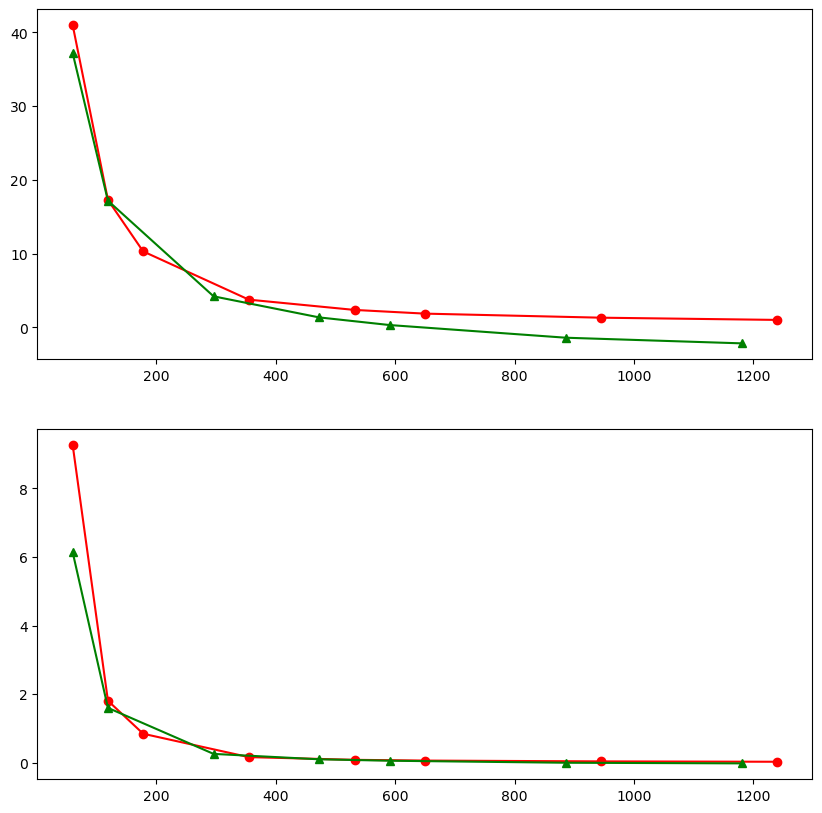

In [48]:
import seaborn as sns
elongation_rate=5
fig, axes = plt.subplots(nrows=2)
axes[0].plot(results[results["stitch"]==False].groupby("long_track").mean().index[:-2],
            results[results["stitch"]==False].groupby("long_track").mean()["elongation_r"].to_numpy()[:-2]-elongation_rate,
            "-o", color="red", )

axes[0].plot(results[results["stitch"]==True].groupby("long_track").mean().index,
            results[results["stitch"]==True].groupby("long_track").mean()["elongation_r"].to_numpy()-elongation_rate,
            "-^", color="green", )


axes[1].plot(results[results["stitch"]==False].groupby("long_track").mean().index[:-2],
            results[results["stitch"]==False].groupby("long_track").mean()["init_translation_r"].to_numpy()[:-2]-0.05,
            "-o", color="red", )

axes[1].plot(results[results["stitch"]==True].groupby("long_track").mean().index,
            results[results["stitch"]==True].groupby("long_track").mean()["init_translation_r"].to_numpy()-0.05,
            "-^", color="green", )


fig.set_size_inches(10,10)
plt.show()
fig.savefig(os.path.join(path_save, "fig2_combine.eps"), dpi=300)

In [43]:
results

,elongation_r,init_translation_r,dt,long_track,k,c,id,stitch
0,28.179490,1.117148,3.0,60,1.132844,1.117148,0,False
1,33.903150,14.714749,3.0,60,1.362941,14.714749,1,False
2,26.030872,0.482558,3.0,60,1.046467,0.482558,2,False
3,26.055242,0.931370,3.0,60,1.047447,0.931370,3,False
4,29.634465,3.863893,3.0,60,1.191335,3.863893,4,False
...,...,...,...,...,...,...,...,...
5345,1.381362,0.008205,3.0,1181,0.055532,0.008205,550,True
5346,1.883162,0.011443,3.0,1181,0.075705,0.011443,560,True
5347,NaN,NaN,3.0,1181,NaN,NaN,570,True
5348,NaN,NaN,3.0,1181,NaN,NaN,580,True


In [ ]:
results[(results.dt == 60.0) & (results.long_track >1000) & (results.elongation_r>0)]

In [ ]:
results_group = results.groupby(["dt", "long_track"]).mean()
results_group.reset_index(inplace=True)

elongation_ref = 24

results_group["elongation_r_diff"] = elongation_ref-results_group['elongation_r']
results_group["elongation_r_ratio"] = 100*results_group["elongation_r"]/elongation_ref - 100
results_group["elongation_r_ratio"]= np.abs(results_group["elongation_r_ratio"])


results_group["init_translation_r_diff"] = 20-results_group['init_translation_r']
results_group["init_translation_r_ratio"] = 100*results_group["init_translation_r"]/20 -100
results_group["init_translation_r_ratio"] = np.abs(results_group["init_translation_r_ratio"])

results_group

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='elongation_r_ratio')

# Create the heatmap
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 6))
# plt.figure(figsize=(8, 6))
ax1 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100,
                 ax=ax1)
# Invert the y-axis
ax1.invert_yaxis()
ax1.set_title("Heatmap of elongation rate Values")
ax1.set_xlabel("time step")
ax1.set_ylabel("track length")



heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')
ax2 = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap="PiYG_r",
                 vmin = 0,
                 vmax = 100, 
                  ax = ax2
                )
# Invert the y-axis
ax2.invert_yaxis()
ax2.set_title("Heatmap of initiation rate Values")
ax2.set_xlabel("time step")
ax2.set_ylabel("track length")

In [ ]:
import seaborn as sns
from matplotlib.colors import ListedColormap
# Create a symmetric colormap
color = plt.cm.coolwarm
color_r = plt.cm.coolwarm_r
combined_colors = ListedColormap(color_r(np.linspace(0, 1, 128)).tolist() +
                                 color(np.linspace(0, 1, 128)).tolist())

heatmap_data = results_group.pivot(index='long_track', columns='dt', values='init_translation_r_ratio')

# Create the heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(heatmap_data, 
                 annot=True, 
                 fmt=".1f", 
                 cmap=combined_colors,
                 vmin = 0,
                 vmax = 200
                )
# Invert the y-axis
ax.invert_yaxis()

plt.title("Heatmap of initiation rate Values")
plt.xlabel("time step")
plt.ylabel("track length")
plt.show()